In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
df = pd.read_csv("survey_results_cleaned.csv")

# numerische & kategorische Features bestimmen
num_cols = df.select_dtypes(include=["float64", "int64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), num_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

In [2]:
svd = TruncatedSVD(n_components=1000)   # z. B. 100 Dimensionen behalten

pca_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("svd", svd)
])


In [3]:
pca_pipeline.fit(df)

#2000 components, ca 6min
#1000 components, ca 1min

,steps,"[('preprocess', ...), ('svd', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


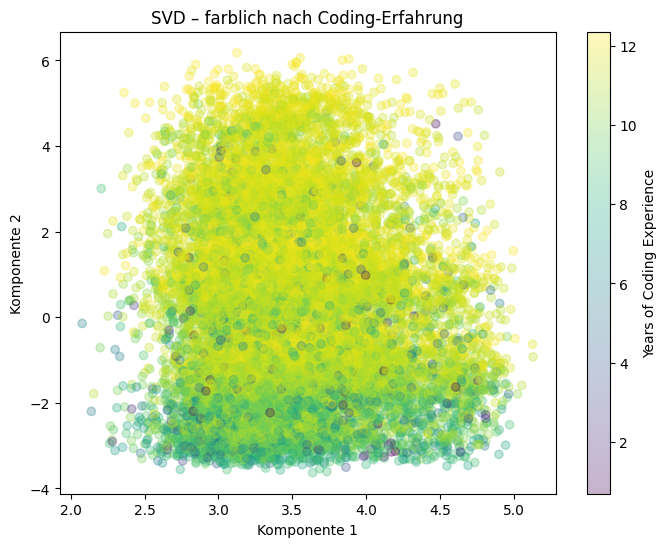

In [8]:
import numpy as np
import matplotlib.pyplot as plt
X_svd = pca_pipeline.transform(df)
df["IncomeLog"] = np.log1p(df["ConvertedCompYearly"])


plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_svd[:, 0],
    X_svd[:, 1],
    c=df["IncomeLog"],
    cmap="viridis",
    alpha=0.3
)

plt.colorbar(scatter, label='Years of Coding Experience')
plt.xlabel("Komponente 1")
plt.ylabel("Komponente 2")
plt.title("SVD – farblich nach Coding-Erfahrung")

plt.show()


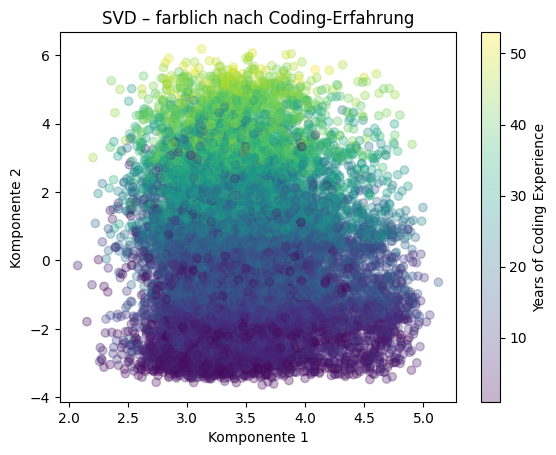

In [6]:
Splt.scatter(X_svd[:,0], X_svd[:,1], c=df["YearsCode"], cmap="viridis", alpha=0.3)
plt.colorbar(label="Years of Coding Experience")
plt.xlabel("Komponente 1")
plt.ylabel("Komponente 2")
plt.title("SVD – farblich nach Coding-Erfahrung")
plt.show()

In [ ]:
svd.explained_variance_ratio_.sum()

In [ ]:
import numpy as np

cum = np.cumsum(svd.explained_variance_ratio_)
plt.plot(cum[:3000])
plt.axhline(0.9, color='red')
plt.title("Kumulative erklärte Varianz")
plt.xlabel("Anzahl Komponenten")
plt.ylabel("Erklärte Varianz")
plt.show()

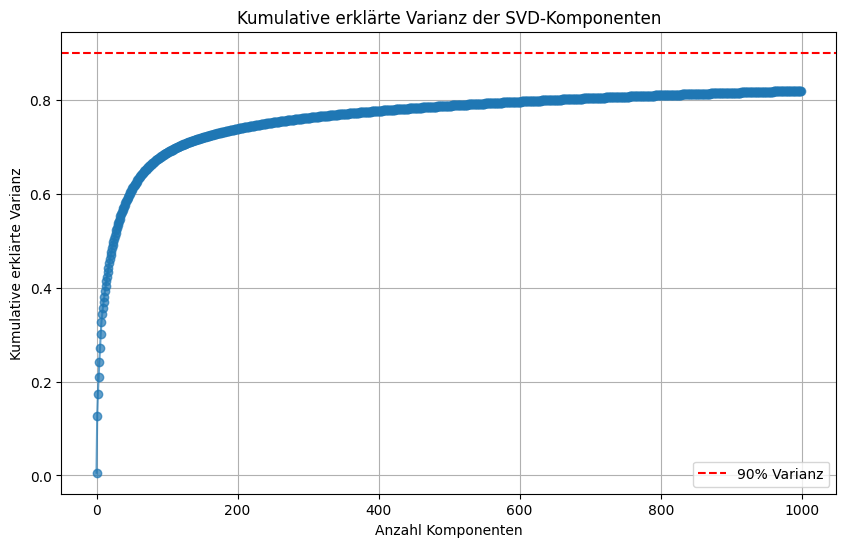

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Varianzen
var = svd.explained_variance_ratio_
cum_var = np.cumsum(var)

plt.figure(figsize=(10, 6))
plt.plot(cum_var, marker='o', linestyle='-', alpha=0.7)

# Hilfslinie bei 90%
plt.axhline(0.90, color='red', linestyle='--', label='90% Varianz')

plt.title("Kumulative erklärte Varianz der SVD-Komponenten")
plt.xlabel("Anzahl Komponenten")
plt.ylabel("Kumulative erklärte Varianz")
plt.legend()
plt.grid(True)

plt.show()


## Kumulative erklärte Varianz der SVD-Komponenten

- zeigt, wie viel Gesamtvarianz durch die ersten SVD-Komponenten erklärt wird
- schnelle Steigung am Anfang, danach deutliche Abflachung
- ca. **82–86 % erklärte Varianz bei 1000 Komponenten**
- keine einzelne dominante Komponente → Varianz breit verteilt
- typisch für hochdimensionale, One-Hot-encodierte Survey-Daten
- **Erkenntnis:** SVD komprimiert effektiv, aber die Daten besitzen keine starke lineare Hauptachse

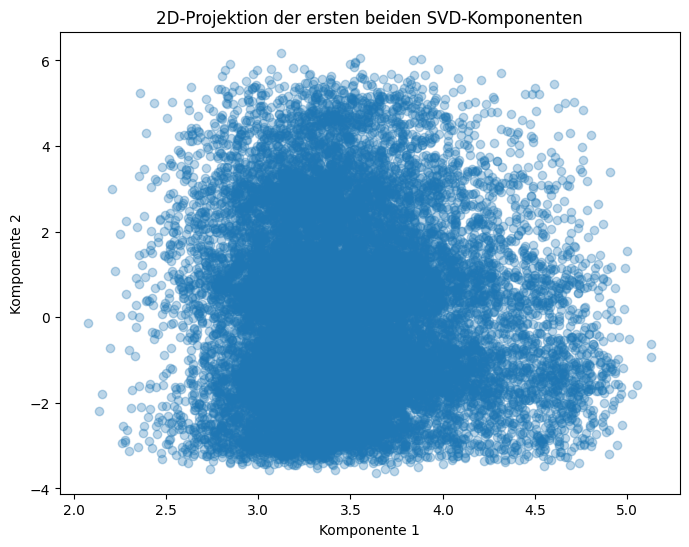

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(X_svd[:, 0], X_svd[:, 1], alpha=0.3)
plt.title("2D-Projektion der ersten beiden SVD-Komponenten")
plt.xlabel("Komponente 1")
plt.ylabel("Komponente 2")
plt.show()

## 2D-Projektion der ersten beiden SVD-Komponenten

- visualisiert die Reduktion von ~50.000 Dimensionen auf 2
- dichte, wolkenartige Punktverteilung ohne klare Cluster
- zeigt hohe Heterogenität im Antwortverhalten der Teilnehmenden
- PC1 & PC2 erfassen nur einen kleinen Anteil der Gesamtstruktur
- typische Form bei Survey-Daten mit vielen kategorialen Merkmalen
- **Erkenntnis:** keine klare Clusterstruktur, aber starke Verdichtung & grundlegende Muster sichtbar

## Haben wir unsere Ziele erreicht?

Ja, die definierten Ziele der Dimensionsreduktion wurden erreicht:

- **Reduktion der Dimensionalität:**
  Der ursprünglich rund 50.000-dimensionale One-Hot-Datensatz wurde mithilfe von TruncatedSVD erfolgreich auf wenige tausend Komponenten verdichtet.
  Bereits 1.000 Komponenten erklären über 82–86 % der Gesamtvarianz.

- **Visualisierung der Datenstruktur:**
  Die Projektion auf die ersten beiden SVD-Komponenten ermöglicht eine grafische Darstellung der hochdimensionalen Daten.
  Obwohl keine klaren Cluster sichtbar sind, zeigt die Visualisierung die starke Heterogenität des Datensatzes und damit die erwartete Grundstruktur.

- **Erkennen latenter Muster:**
  Die Analyse hat gezeigt, dass bestimmte Variablen (z. B. Coding-Erfahrung) teilweise mit den SVD-Komponenten korrelieren.
  Dies bestätigt, dass die Dimensionsreduktion relevante Muster aus den Daten extrahiert.

- **Bewertung der linearen Struktur:**
  Die flache Varianzkurve und die diffuse Punktwolke zeigen, dass der Datensatz keine dominante lineare Struktur besitzt – eine wichtige Erkenntnis für die weitere Analyse.

**Fazit:**
Die Ziele der Verdichtung, Visualisierung und strukturellen Analyse wurden vollständig erreicht.
Gleichzeitig liefert die Dimensionsreduktion wertvolle Einsichten in die Komplexität und Hete